In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Считываем данные

In [258]:
path=r"C:\Users\kiril\OneDrive\Рабочий стол\jupyter_projects\household_power_consumption.txt"

df = pd.read_csv(path,sep=';' ,parse_dates={'datetime': [0, 1]}, dayfirst=True,na_values=['?', 'Nan'])

C:\Users\kiril\AppData\Local\Temp\ipykernel_12552\3367679095.py:3: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(path,sep=';' ,parse_dates={'datetime': [0, 1]}, dayfirst=True,na_values=['?', 'Nan'])


In [259]:
df.set_index('datetime', inplace=True)

df_month = df.loc['2007-01'].copy() 
df_month = df_month.sort_index()

df_month['lag_60'] = df_month['Global_active_power'].shift(60)

df_month['lag_1440'] = df_month['Global_active_power'].shift(1440)




# **EDA**

In [260]:
columns=['Global_active_power'	,'Global_reactive_power'	,'Voltage'	,'Global_intensity'	,'Sub_metering_1'	,'Sub_metering_2'	,'Sub_metering_3']
for column_name in columns:
    q1 = df_month[column_name].quantile(0.25)
    q3 = df_month[column_name].quantile(0.75)
    IQR = q3 - q1
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR
    
    outliers = df_month[(df[column_name] < lower_bound) | (df_month[column_name] > upper_bound)]
    
    print(f"Столбец '{column_name}': {len(outliers)} выбросов ({len(outliers)/len(df_month)*100:.2f}%)")

C:\Users\kiril\AppData\Local\Temp\ipykernel_12552\3931134914.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  outliers = df_month[(df[column_name] < lower_bound) | (df_month[column_name] > upper_bound)]


Столбец 'Global_active_power': 835 выбросов (1.87%)


C:\Users\kiril\AppData\Local\Temp\ipykernel_12552\3931134914.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  outliers = df_month[(df[column_name] < lower_bound) | (df_month[column_name] > upper_bound)]


Столбец 'Global_reactive_power': 421 выбросов (0.94%)


C:\Users\kiril\AppData\Local\Temp\ipykernel_12552\3931134914.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  outliers = df_month[(df[column_name] < lower_bound) | (df_month[column_name] > upper_bound)]


...

Столбец 'Sub_metering_1': 3721 выбросов (8.34%)


C:\Users\kiril\AppData\Local\Temp\ipykernel_12552\3931134914.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  outliers = df_month[(df[column_name] < lower_bound) | (df_month[column_name] > upper_bound)]


Столбец 'Sub_metering_2': 2527 выбросов (5.66%)


C:\Users\kiril\AppData\Local\Temp\ipykernel_12552\3931134914.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  outliers = df_month[(df[column_name] < lower_bound) | (df_month[column_name] > upper_bound)]


Столбец 'Sub_metering_3': 0 выбросов (0.00%)


# Графики выбросов

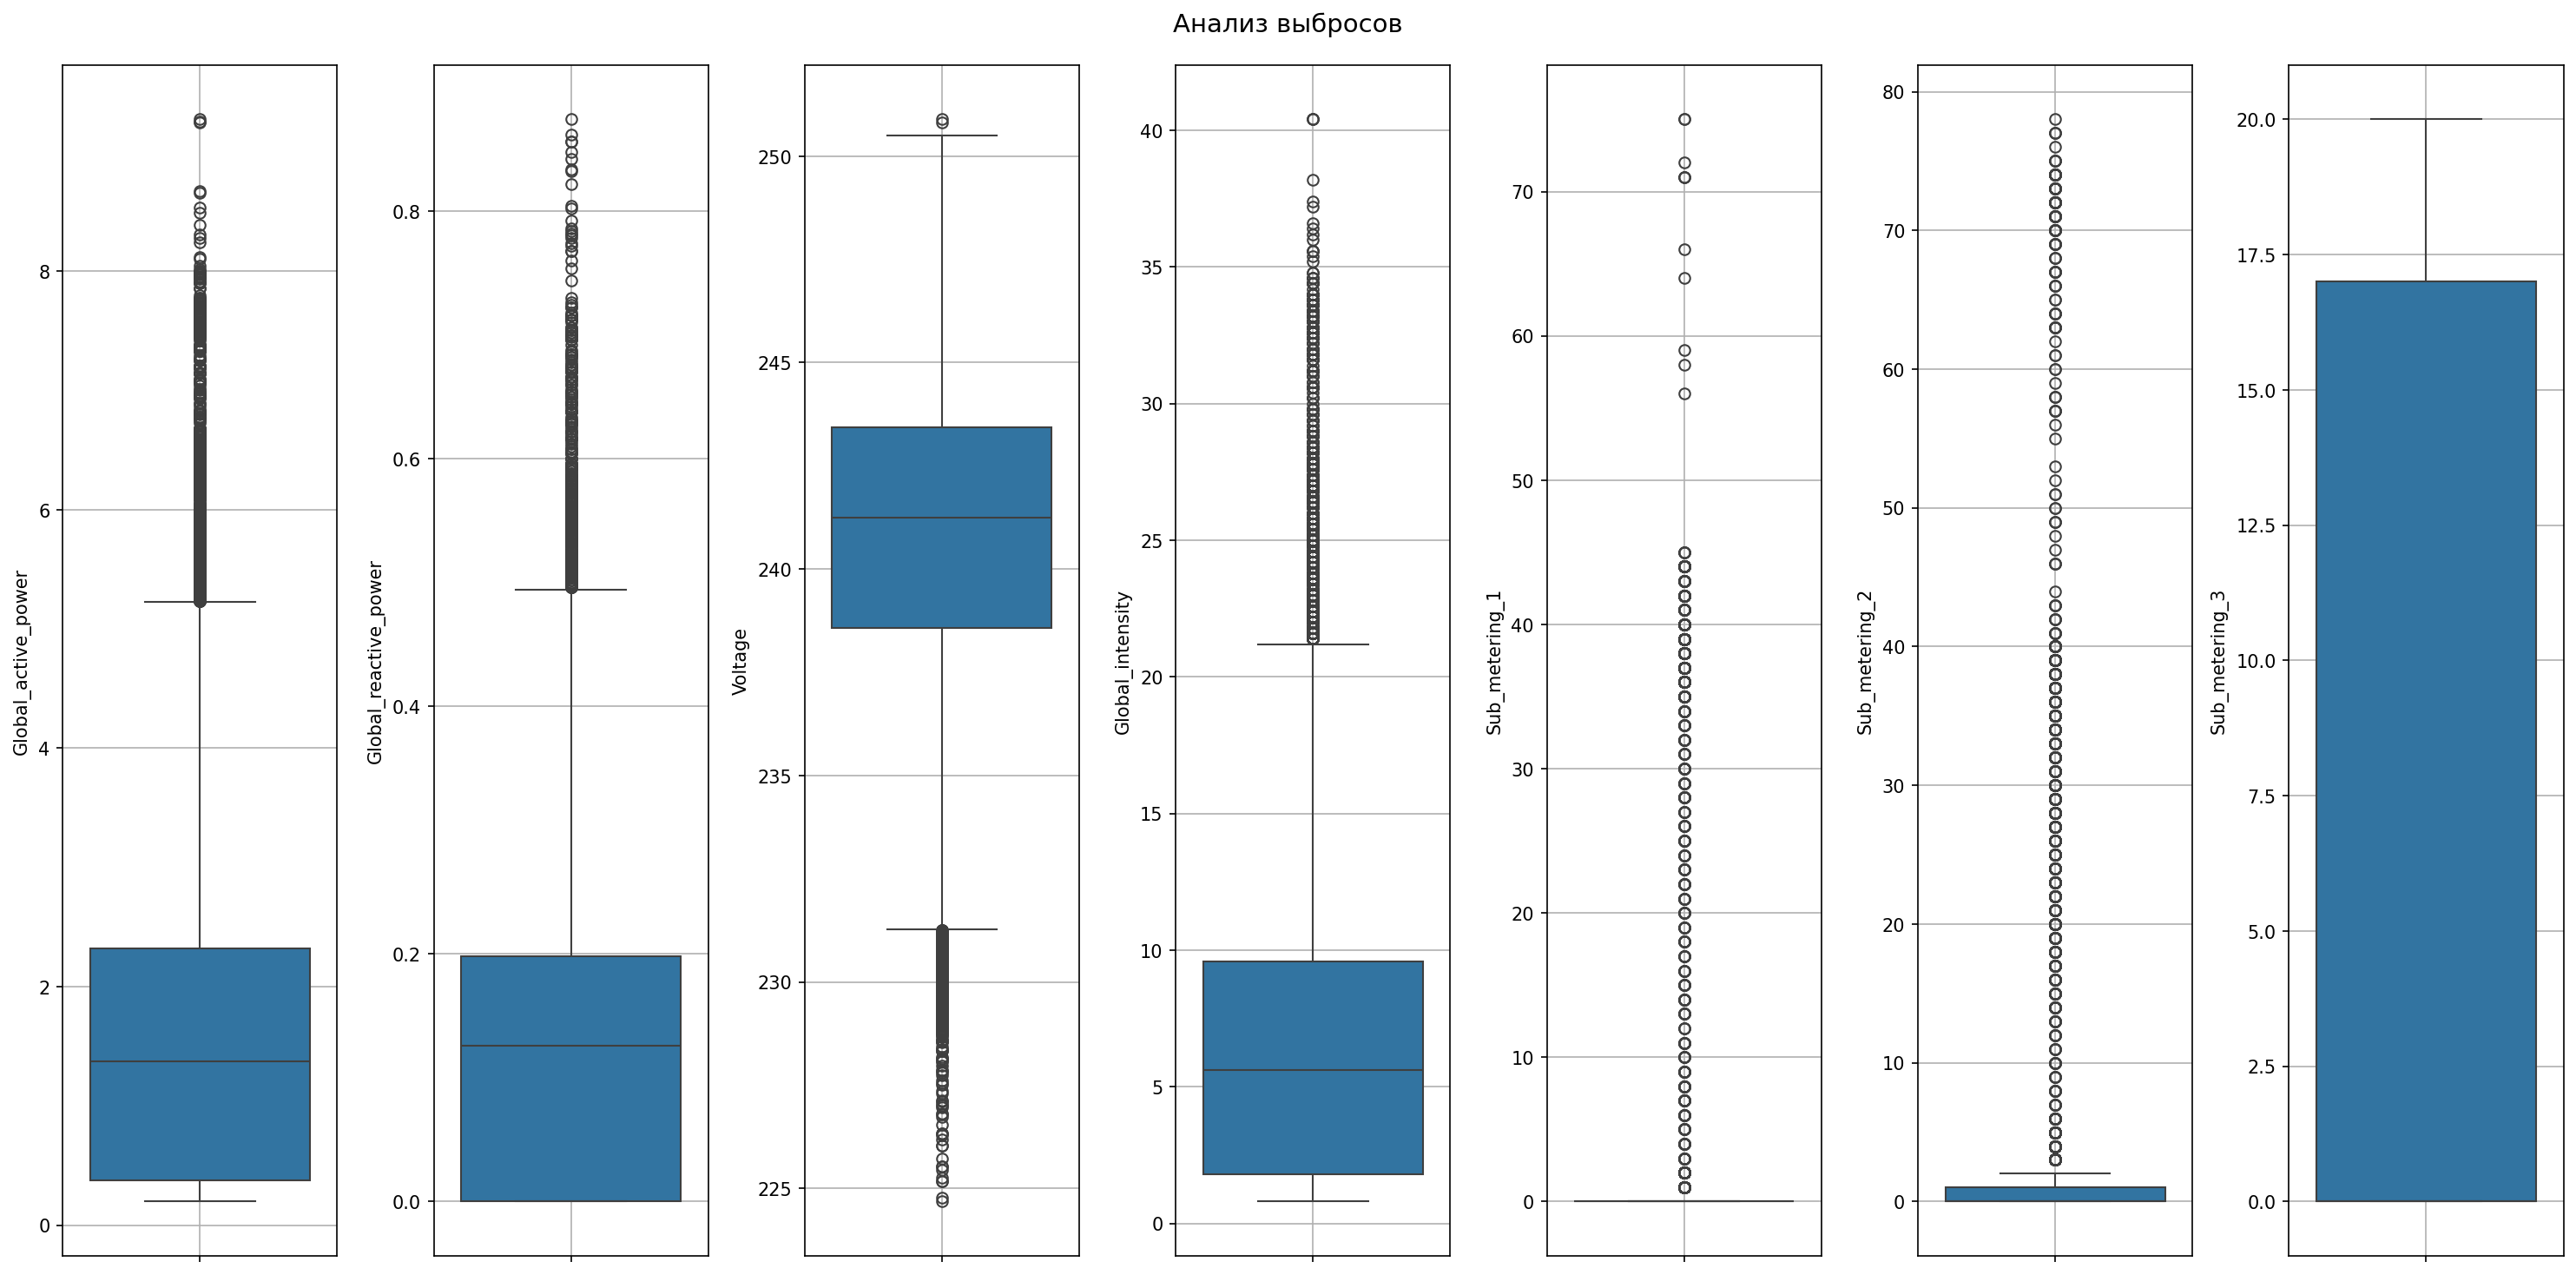

In [261]:
fig,ax=plt.subplots(nrows=1,ncols=7,figsize=(20,10),dpi=150)
ax=ax.flatten()
index=0

for column_name in columns:
    sns.boxplot(y=column_name,data=df_month,ax=ax[index])
    ax[index].grid(True)
    index+=1
fig.suptitle("Анализ выбросов",fontsize=14)
plt.tight_layout(pad=1.5, w_pad=1, h_pad=5.0)

# Графики распределений

Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'lag_60', 'lag_1440'],
      dtype='object')


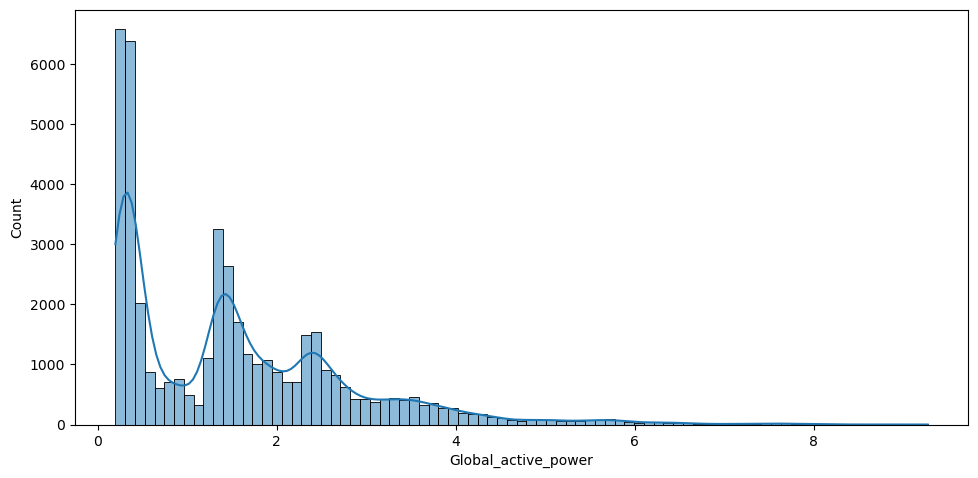

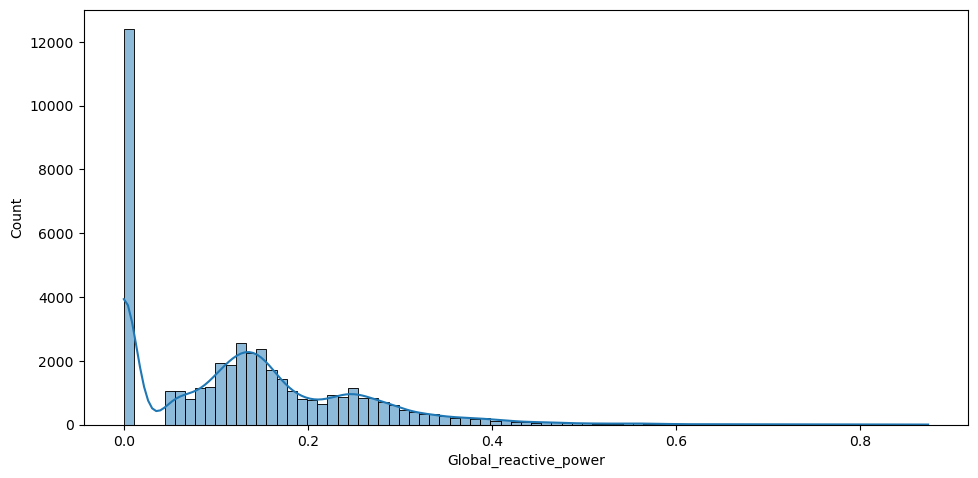

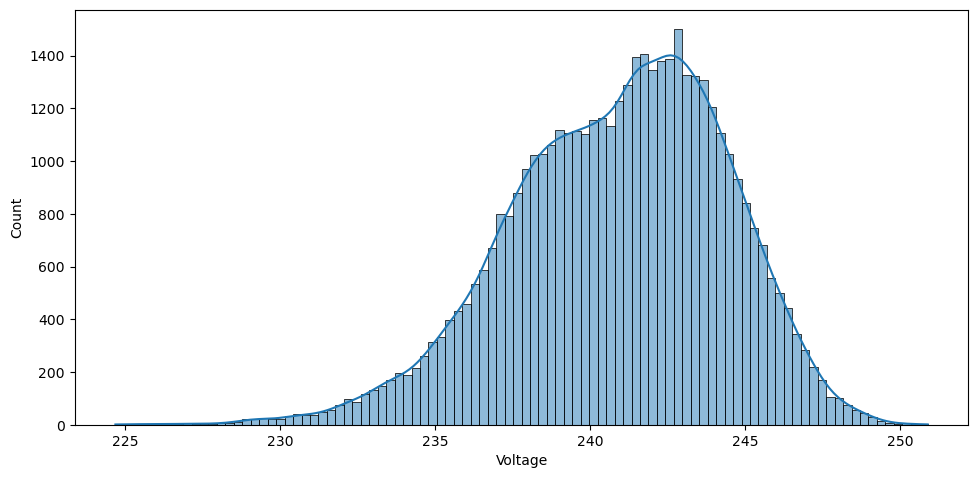

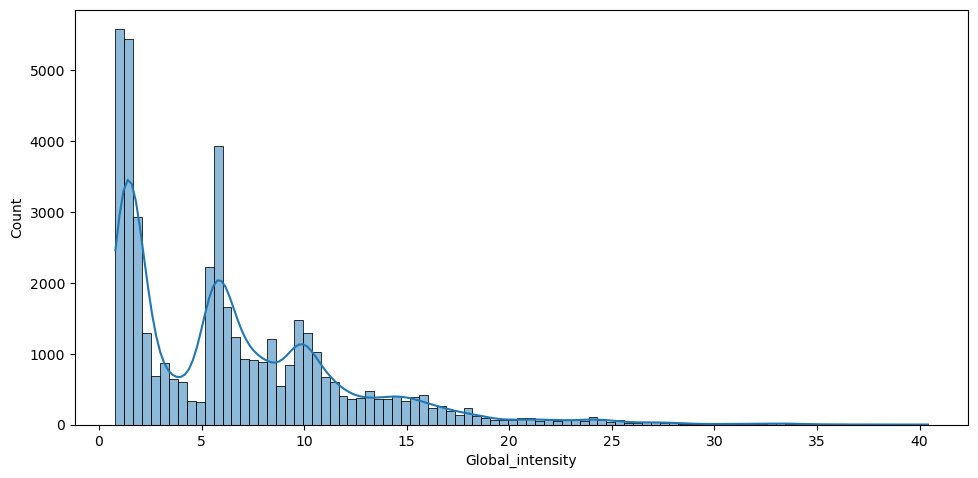

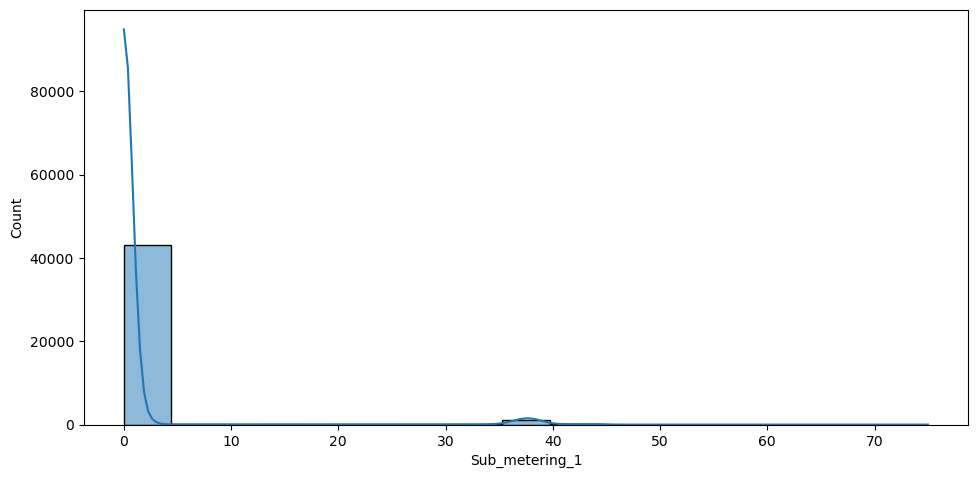

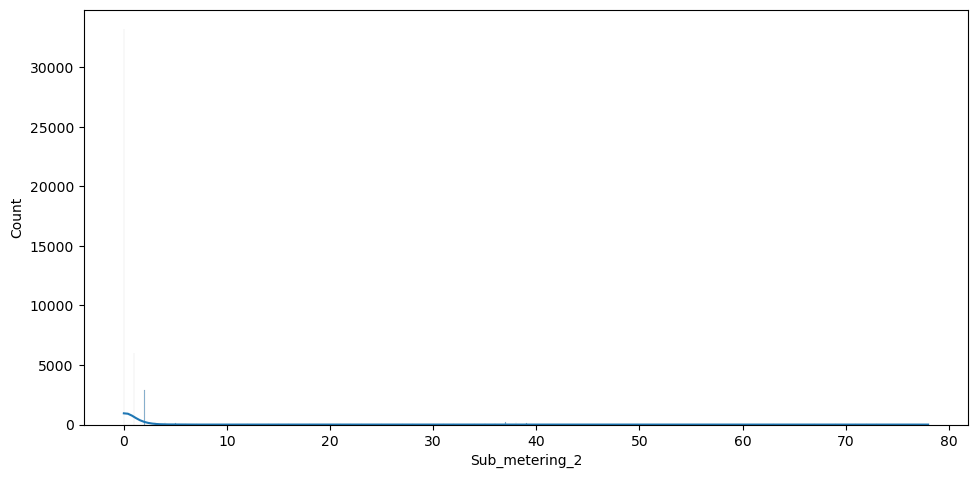

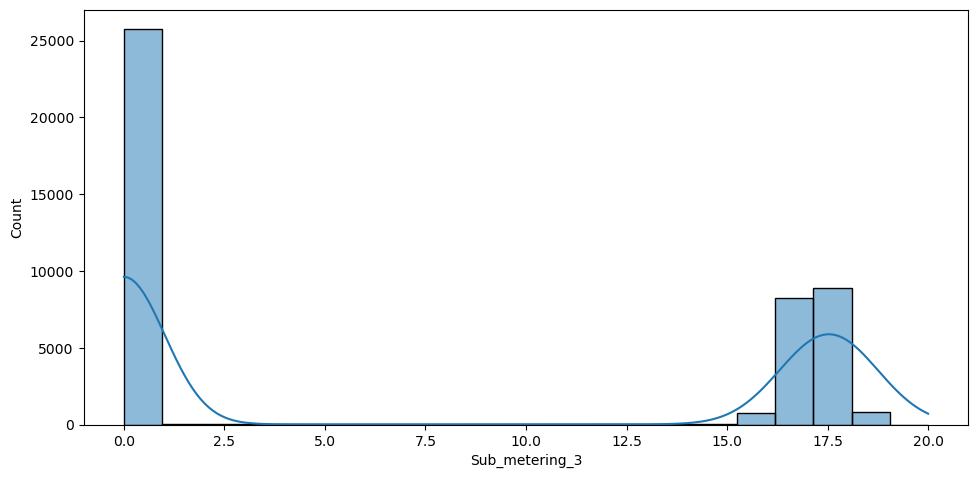

In [262]:
print(df_month.columns)

for column_name in columns:
    plt.figure(figsize=(10,5))
    sns.histplot(x=column_name,data=df_month,kde=True)
    index+=1
    fig.suptitle(f"Анализ распределения{column_name}",fontsize=14)
    plt.tight_layout(pad=1.5, w_pad=1, h_pad=5.0)

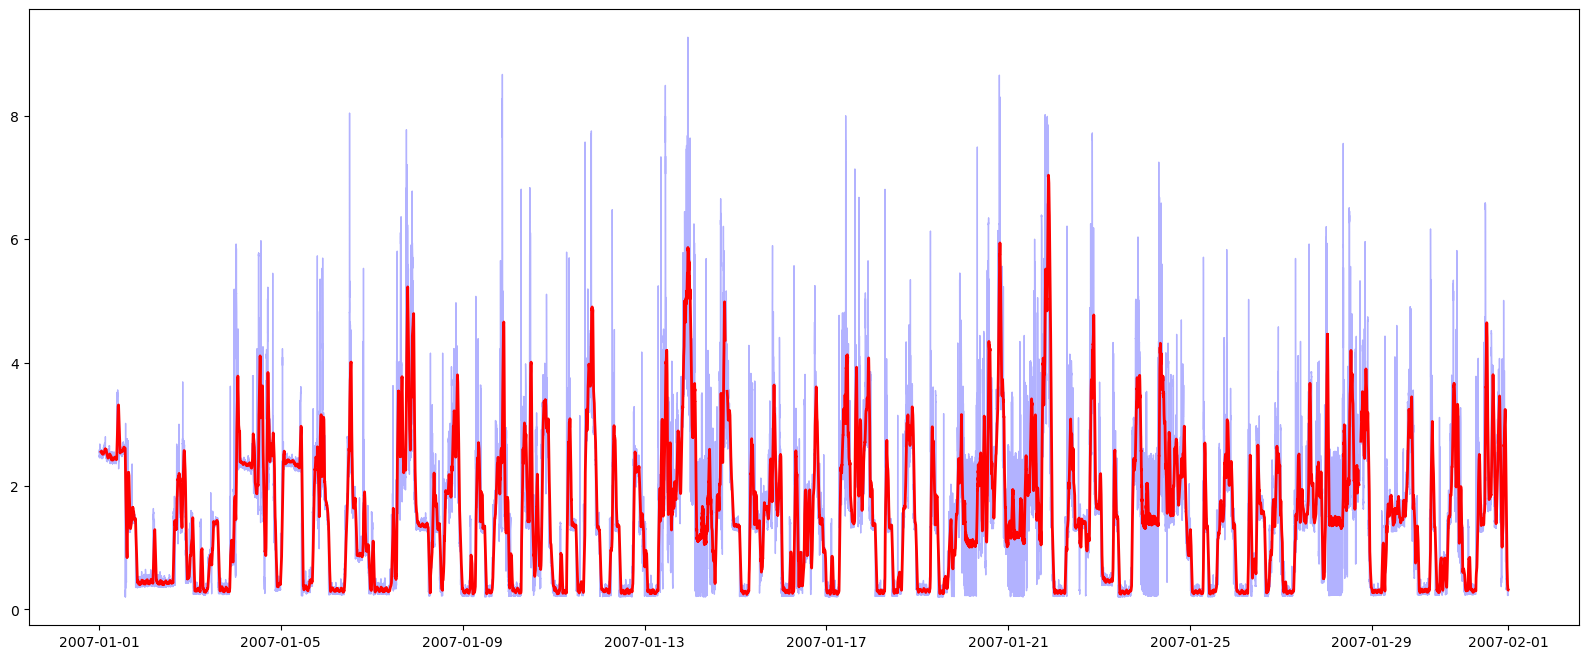

In [263]:
plt.figure(figsize=(20, 8))

data_to_plot = df_month['Global_active_power']

plt.plot(data_to_plot.index, data_to_plot, 
         label='Original Signal (1 min)', 
         color='blue', 
         alpha=0.3, 
         linewidth=1)


rolling_mean = data_to_plot.rolling(window=60).mean()

plt.plot(rolling_mean.index, rolling_mean, 
         label='Rolling Mean (1 hour)', 
         color='red', 
         linewidth=2)

#### График энергопотребления не ровный,есть явные счачки.Ниже графики за первую неделю.

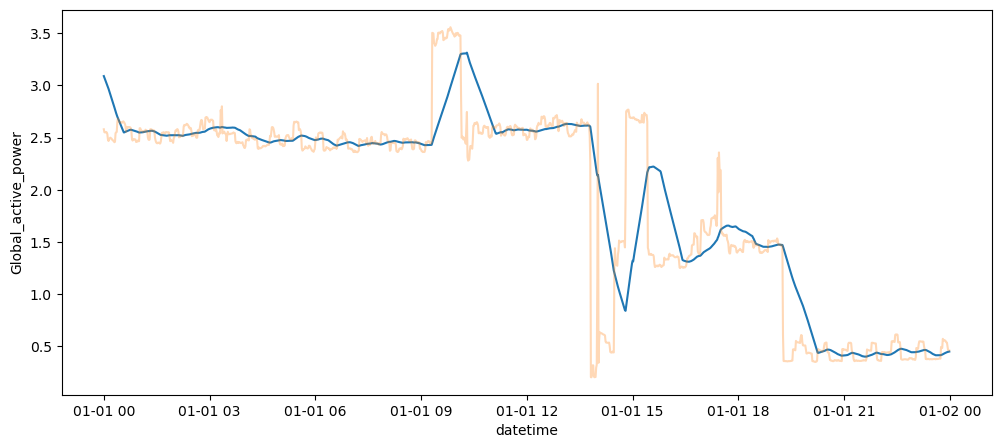

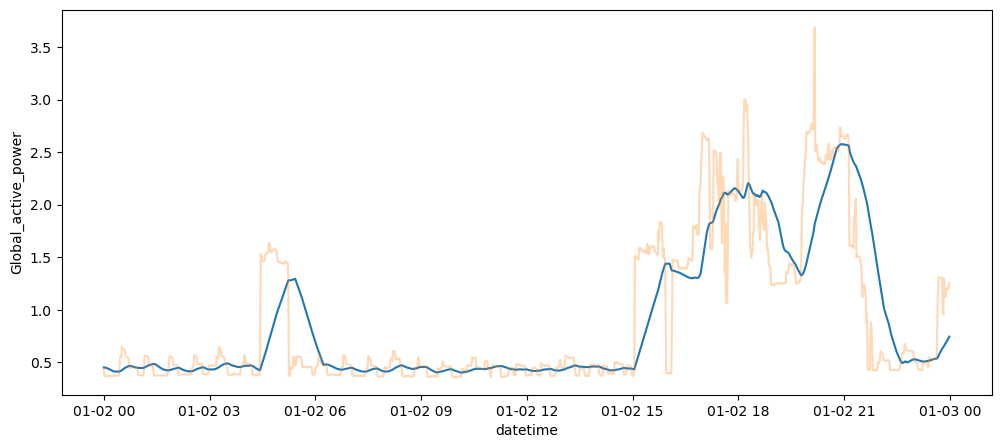

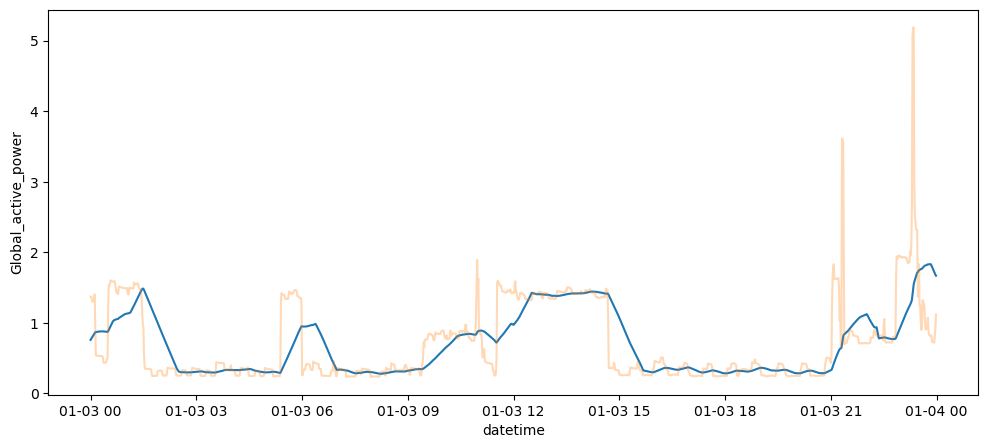

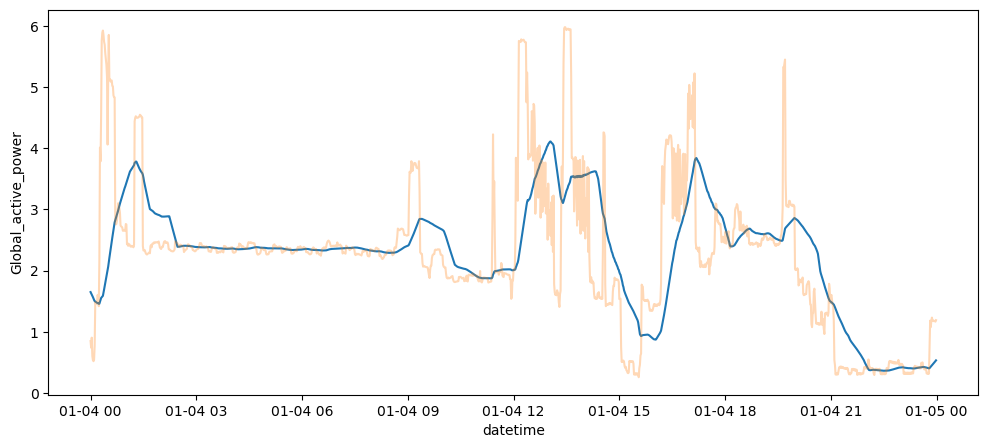

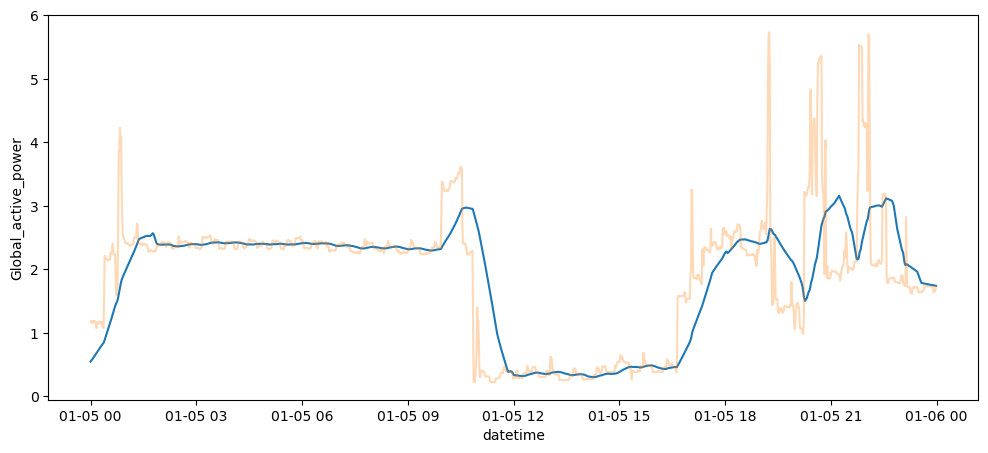

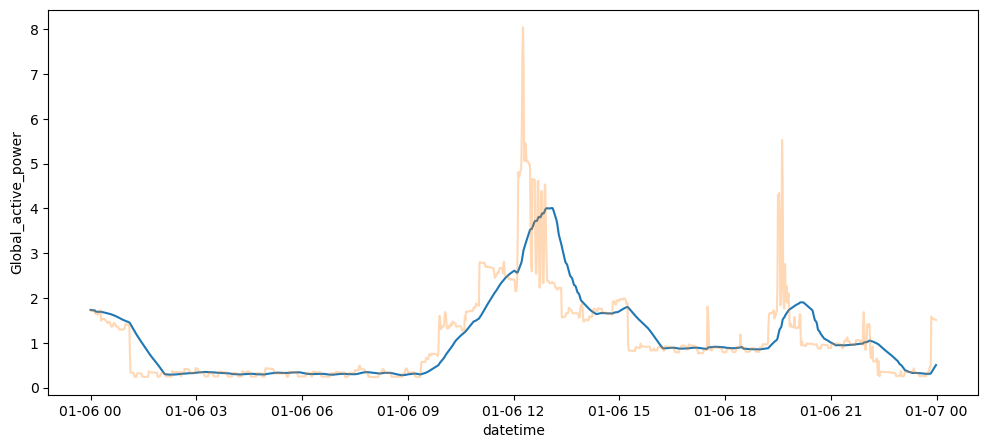

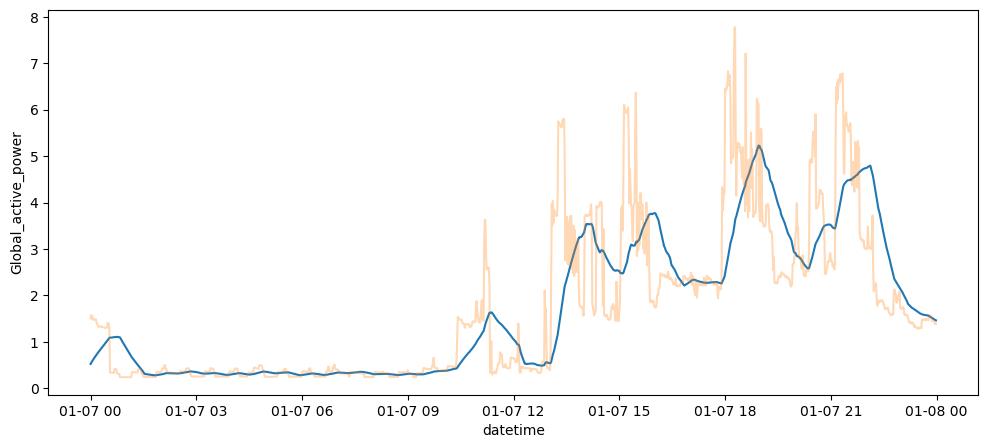

In [264]:
smooth_data = df['Global_active_power'].rolling(window=60).mean()

for i in range(1,8):
    index=f'2007-01-0{i}'
    index=str(index)
    one_day_data = smooth_data.loc[index]
    plt.figure(figsize=(12,5))
    sns.lineplot(one_day_data)
    sns.lineplot(df['Global_active_power'].loc[index], alpha=0.3)

В период с 00:00 до 06:00-07:00 потребление обычно минимально и стабильно (2-3кВт/ч).

Отчетливо видны всплески активности утром (сборы на работу) и резкие скачки вечером (18:00 - 22:00).

В выходные дни резкие скачки начинаются с 12 часов и продолжаются до 00.Однако самый пик скачков находится около : 13:00 и 20:00

In [265]:
df_month.isna().sum()

Global_active_power         2
Global_reactive_power       2
Voltage                     2
Global_intensity            2
Sub_metering_1              2
Sub_metering_2              2
Sub_metering_3              2
lag_60                     62
lag_1440                 1442
dtype: int64

In [266]:
df_month.tail()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,lag_60,lag_1440
datetime,,,,,,,,,
2007-01-31 23:55:00,0.334,0.130,243.80,1.4,0.0,0.0,0.0,0.322,0.544
2007-01-31 23:56:00,0.332,0.126,243.26,1.4,0.0,0.0,0.0,0.322,0.544
2007-01-31 23:57:00,0.328,0.124,242.59,1.4,0.0,0.0,0.0,0.342,0.546
2007-01-31 23:58:00,0.328,0.126,242.87,1.4,0.0,0.0,0.0,0.348,0.548
2007-01-31 23:59:00,0.326,0.126,242.80,1.4,0.0,0.0,0.0,0.346,0.548


In [267]:
rows_with_nan = df_month[df_month.isna().any(axis=1)]
rows_with_nan.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,lag_60,lag_1440
datetime,,,,,,,,,
2007-01-01 00:00:00,2.580,0.136,241.97,10.6,0.0,0.0,0.0,NaN,NaN
2007-01-01 00:01:00,2.552,0.100,241.75,10.4,0.0,0.0,0.0,NaN,NaN
2007-01-01 00:02:00,2.550,0.100,241.64,10.4,0.0,0.0,0.0,NaN,NaN
2007-01-01 00:03:00,2.550,0.100,241.71,10.4,0.0,0.0,0.0,NaN,NaN
2007-01-01 00:04:00,2.554,0.100,241.98,10.4,0.0,0.0,0.0,NaN,NaN


In [268]:
df_month[columns] = df_month[columns].fillna(method='ffill')

C:\Users\kiril\AppData\Local\Temp\ipykernel_12552\1761136213.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_month[columns] = df_month[columns].fillna(method='ffill')


In [269]:
df_month[['lag_60'	,'lag_1440']]=df_month[['lag_60'	,'lag_1440']].fillna(0)

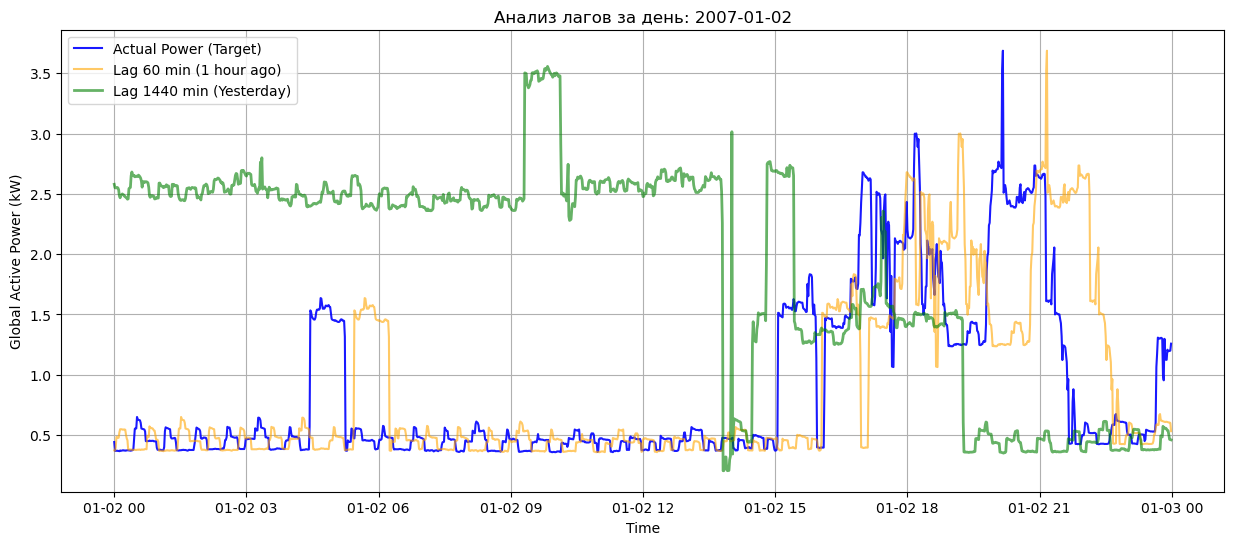

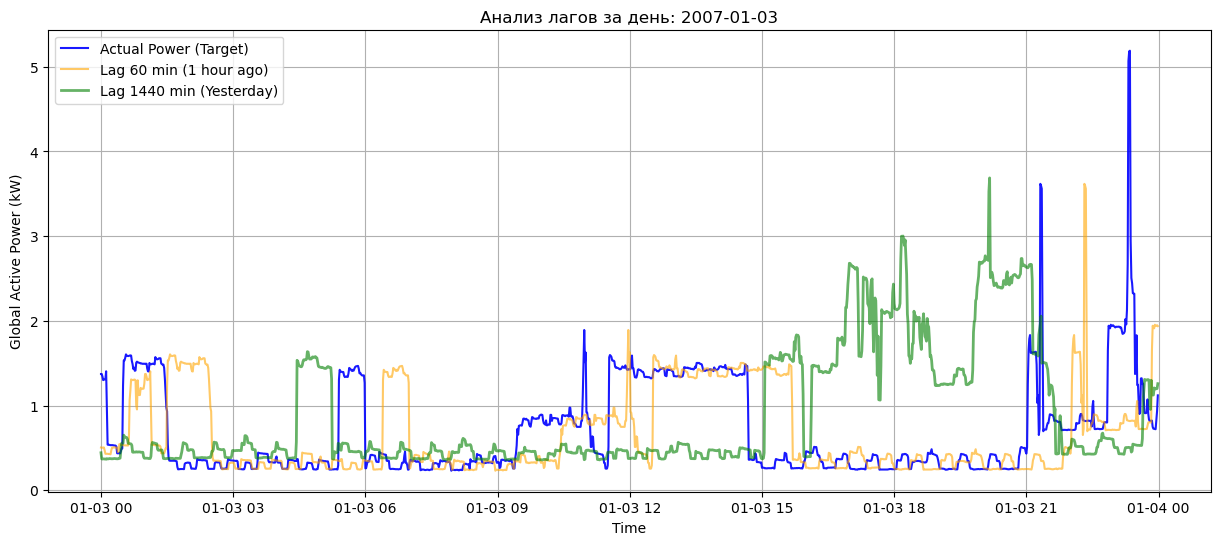

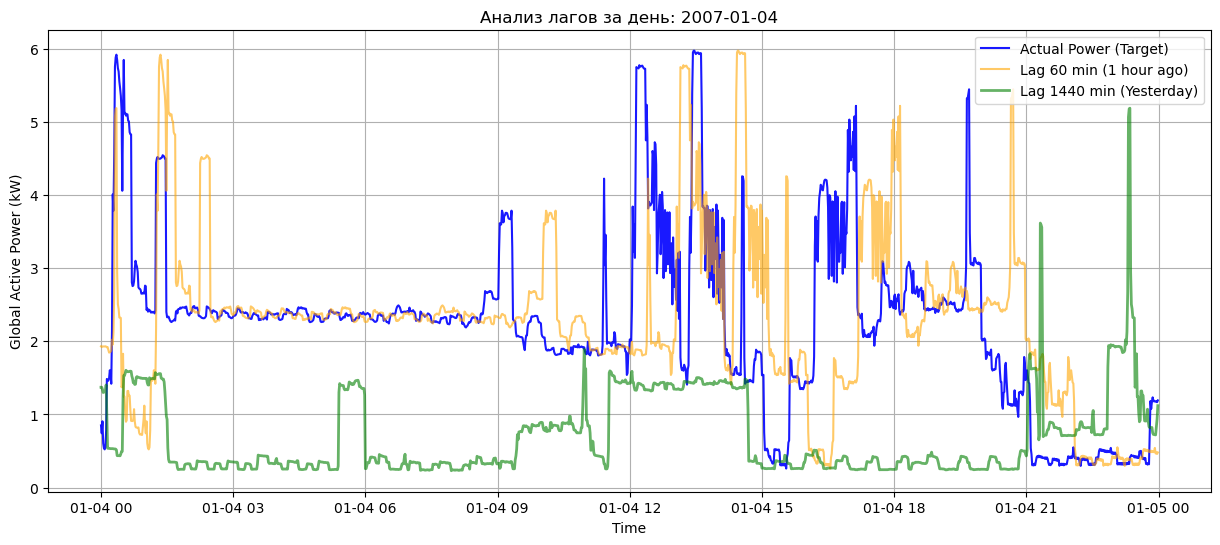

In [270]:
for i in range(2, 5): 
    date_str = f'2007-01-0{i}'
    daily_data = df_month.loc[date_str]
    plt.figure(figsize=(15, 6))
    sns.lineplot(data=daily_data['Global_active_power'], label='Actual Power (Target)', color='blue', linewidth=1.5, alpha=0.9)
    sns.lineplot(data=daily_data['lag_60'], label='Lag 60 min (1 hour ago)',color='orange', alpha=0.6)
    sns.lineplot(data=daily_data['lag_1440'], label='Lag 1440 min (Yesterday)', color='green', linewidth=2, alpha=0.6)
    plt.title(f"Анализ лагов за день: {date_str}")
    plt.ylabel("Global Active Power (kW)")
    plt.xlabel("Time")
    plt.legend()
    plt.grid(True)

# Стационарность

In [271]:
result = adfuller(df_month['Global_active_power'])

result[1]

4.0418833195986727e-22

**p-value<0.05 => ряд стационарен**

# Разбиение train_test_split


In [272]:

X=df_month.drop('Global_active_power',axis=1)
y=df_month.drop(X,axis=1)

In [273]:
y

,Global_active_power
datetime,
2007-01-01 00:00:00,2.580
2007-01-01 00:01:00,2.552
2007-01-01 00:02:00,2.550
2007-01-01 00:03:00,2.550
2007-01-01 00:04:00,2.554
...,...
2007-01-31 23:55:00,0.334
2007-01-31 23:56:00,0.332
2007-01-31 23:57:00,0.328


In [274]:
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,  shuffle=False)

# Linear Regression

In [275]:
model_linear=LinearRegression()
model_linear.fit(X_train,y_train)

LinearRegression()

In [276]:
linear_pred=model_linear.predict(X_val)

mae_lr = mean_absolute_error(y_val, linear_pred)
rmse_lr = mean_squared_error(y_val, linear_pred,squared=False)

print(f"MAE : {mae_lr}")
print(f"RMSE : {rmse_lr}")

MAE : 0.029612517802252002
RMSE : 0.051893617951904614


c:\Users\kiril\anaconda3\envs\MLops_main\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# GradintBoosting

In [277]:
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8
)

gbr.fit(X_train, y_train)


c:\Users\kiril\anaconda3\envs\MLops_main\Lib\site-packages\sklearn\ensemble\_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


GradientBoostingRegressor(learning_rate=0.05, max_depth=6, n_estimators=300,
                          subsample=0.8)

In [278]:
gbr_pred=gbr.predict(X_val)
mae_gbr = mean_absolute_error(y_val, gbr_pred)
rmse_gbr = mean_squared_error(y_val, gbr_pred,squared=False)

print(f"MAE : {mae_gbr}")
print(f"RMSE : {rmse_gbr}")

MAE : 0.023349276290081898
RMSE : 0.04068409202694296


c:\Users\kiril\anaconda3\envs\MLops_main\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# Random Forest

In [279]:
rf_model = RandomForestRegressor(n_estimators=1000, max_depth=12, random_state=42,n_jobs=-1)
rf_model.fit(X_train,y_train)

c:\Users\kiril\anaconda3\envs\MLops_main\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(max_depth=12, n_estimators=1000, n_jobs=-1,
                      random_state=42)

In [280]:
rf_pred=rf_model.predict(X_val)
mae_rf = mean_absolute_error(y_val, rf_pred)
rmse_rf = mean_squared_error(y_val, rf_pred,squared=False)

print(f"MAE : {mae_rf}")
print(f"RMSE : {rmse_rf}")

MAE : 0.026398474471270503
RMSE : 0.04757224098395896


c:\Users\kiril\anaconda3\envs\MLops_main\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# XGBoost

In [281]:
xg_reg = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,         
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    n_jobs=-1,
    random_state=42
)
xg_reg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [282]:
xg_pred=xg_reg.predict(X_val)
mae_xg = mean_absolute_error(y_val, xg_pred)
rmse_xg = mean_squared_error(y_val, xg_pred,squared=False)

print(f"MAE : {mae_xg}")
print(f"RMSE : {rmse_xg}")

MAE : 0.023260541949154123
RMSE : 0.04084668643773868


c:\Users\kiril\anaconda3\envs\MLops_main\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# Создание тесового датасета


In [283]:
df_test = df.loc['2007-02']
df_test=df_test[:'2007-02-16']

df_test['lag_60'] = df_test['Global_active_power'].shift(60)

df_test['lag_1440'] = df_test['Global_active_power'].shift(1440)
df_test=df_test.fillna(0)

In [284]:
df_test.tail()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,lag_60,lag_1440
datetime,,,,,,,,,
2007-02-16 23:55:00,1.952,0.266,240.24,8.2,0.0,1.0,17.0,1.644,1.656
2007-02-16 23:56:00,1.990,0.336,240.40,8.4,0.0,2.0,18.0,1.654,1.600
2007-02-16 23:57:00,1.988,0.336,240.52,8.4,0.0,1.0,18.0,1.648,1.562
2007-02-16 23:58:00,1.988,0.338,240.62,8.2,0.0,2.0,17.0,1.642,1.532
2007-02-16 23:59:00,1.992,0.340,240.87,8.4,0.0,1.0,18.0,1.646,1.610


In [285]:
X_test=df_test.drop('Global_active_power',axis=1)
y_test=df_test.drop(X,axis=1)

In [286]:
X_test

,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,lag_60,lag_1440
datetime,,,,,,,,
2007-02-01 00:00:00,0.128,243.15,1.4,0.0,0.0,0.0,0.000,0.000
2007-02-01 00:01:00,0.130,243.32,1.4,0.0,0.0,0.0,0.000,0.000
2007-02-01 00:02:00,0.132,243.51,1.4,0.0,0.0,0.0,0.000,0.000
2007-02-01 00:03:00,0.134,243.90,1.4,0.0,0.0,0.0,0.000,0.000
2007-02-01 00:04:00,0.130,243.16,1.4,0.0,0.0,0.0,0.000,0.000
...,...,...,...,...,...,...,...,...
2007-02-16 23:55:00,0.266,240.24,8.2,0.0,1.0,17.0,1.644,1.656
2007-02-16 23:56:00,0.336,240.40,8.4,0.0,2.0,18.0,1.654,1.600
2007-02-16 23:57:00,0.336,240.52,8.4,0.0,1.0,18.0,1.648,1.562


In [287]:
y_test

,Global_active_power
datetime,
2007-02-01 00:00:00,0.326
2007-02-01 00:01:00,0.326
2007-02-01 00:02:00,0.324
2007-02-01 00:03:00,0.324
2007-02-01 00:04:00,0.322
...,...
2007-02-16 23:55:00,1.952
2007-02-16 23:56:00,1.990
2007-02-16 23:57:00,1.988


# LinearRegression Test

In [288]:
linear_pred=model_linear.predict(X_test)

mae_lr = mean_absolute_error(y_test, linear_pred)
rmse_lr = mean_squared_error(y_test, linear_pred,squared=False)

print(f"MAE : {mae_lr}")
print(f"RMSE : {rmse_lr}")

MAE : 0.030260016156522483
RMSE : 0.0498464076267408


c:\Users\kiril\anaconda3\envs\MLops_main\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


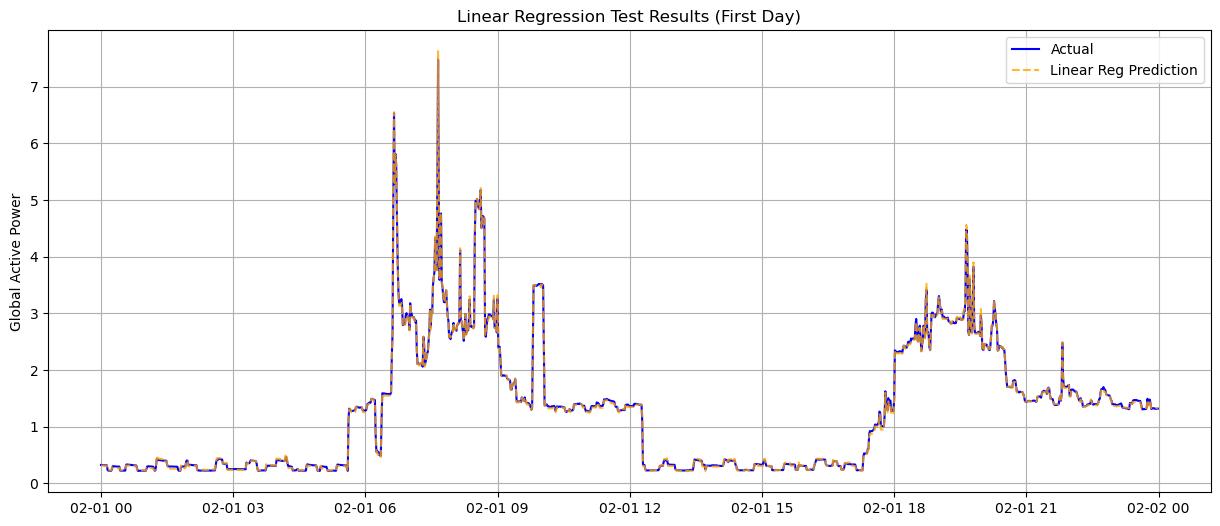

In [289]:
plt.figure(figsize=(15, 6))
subset = 1440

plt.plot(y_test.index[:subset], y_test.iloc[:subset], label='Actual', color='blue', linewidth=1.5)
plt.plot(y_test.index[:subset], linear_pred[:subset], label='Linear Reg Prediction', color='orange', linestyle='--', alpha=0.8)

plt.title('Linear Regression Test Results (First Day)')
plt.ylabel('Global Active Power')
plt.legend()
plt.grid(True)


# GradientBoosting Test

In [290]:
gbr_pred=gbr.predict(X_test)
mae_gbr = mean_absolute_error(y_test, gbr_pred)
rmse_gbr = mean_squared_error(y_test, gbr_pred,squared=False)

print(f"MAE : {mae_gbr}")
print(f"RMSE : {rmse_gbr}")

MAE : 0.024340027180402353
RMSE : 0.042040103313832206


c:\Users\kiril\anaconda3\envs\MLops_main\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


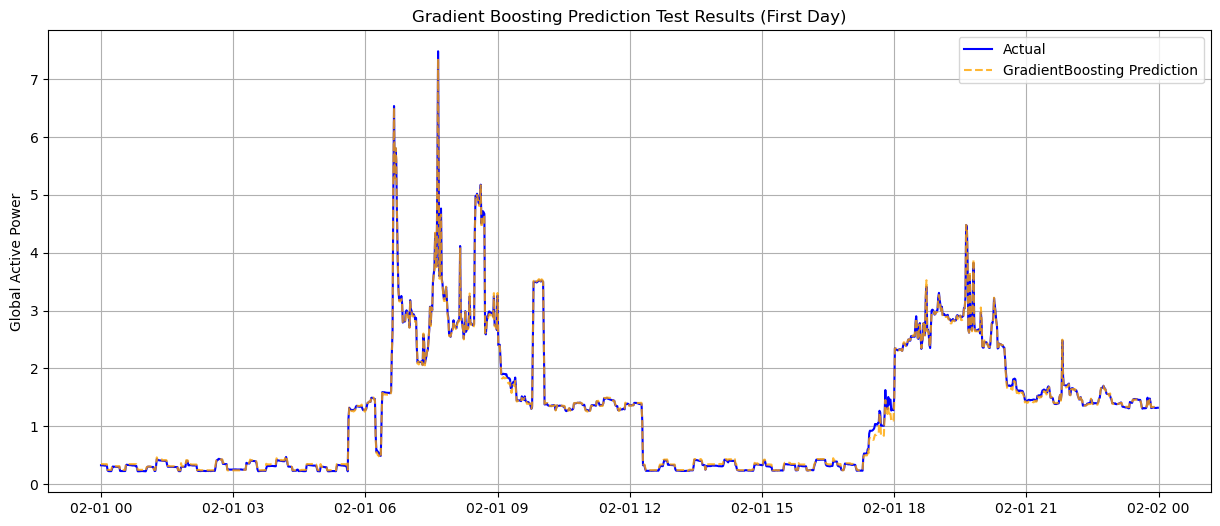

In [291]:
plt.figure(figsize=(15, 6))
subset = 1440 

plt.plot(y_test.index[:subset], y_test.iloc[:subset], label='Actual', color='blue', linewidth=1.5)
plt.plot(y_test.index[:subset], gbr_pred[:subset], label='GradientBoosting Prediction', color='orange', linestyle='--', alpha=0.8)

plt.title('Gradient Boosting Prediction Test Results (First Day)')
plt.ylabel('Global Active Power')
plt.legend()
plt.grid(True)

# RandomForest Test

In [292]:
rf_pred=rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = mean_squared_error(y_test, rf_pred,squared=False)

print(f"MAE : {mae_rf}")
print(f"RMSE : {rmse_rf}")

MAE : 0.02733999483259997
RMSE : 0.047450547673950634


c:\Users\kiril\anaconda3\envs\MLops_main\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


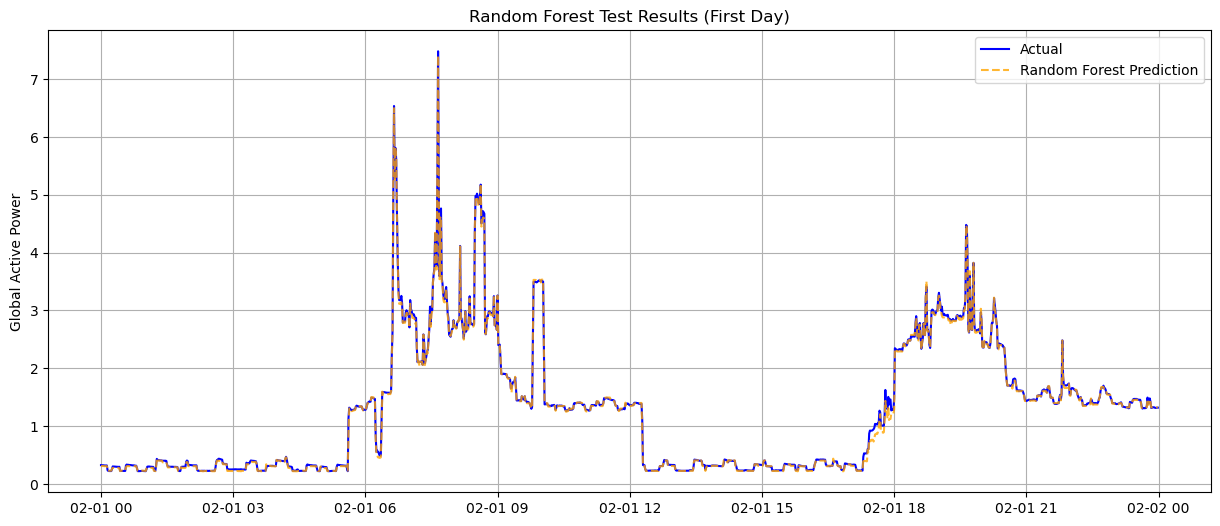

In [293]:
plt.figure(figsize=(15, 6))
subset = 1440 

plt.plot(y_test.index[:subset], y_test.iloc[:subset], label='Actual', color='blue', linewidth=1.5)
plt.plot(y_test.index[:subset], rf_pred[:subset], label='Random Forest Prediction', color='orange', linestyle='--', alpha=0.8)

plt.title('Random Forest Test Results (First Day)')
plt.ylabel('Global Active Power')
plt.legend()
plt.grid(True)

# XGBoost

In [294]:
xg_pred=xg_reg.predict(X_test)
mae_xg = mean_absolute_error(y_test, xg_pred)
rmse_xg = mean_squared_error(y_test, xg_pred,squared=False)

print(f"MAE : {mae_xg}")
print(f"RMSE : {rmse_xg}")

MAE : 0.024114804157278395
RMSE : 0.041592681896859975


c:\Users\kiril\anaconda3\envs\MLops_main\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


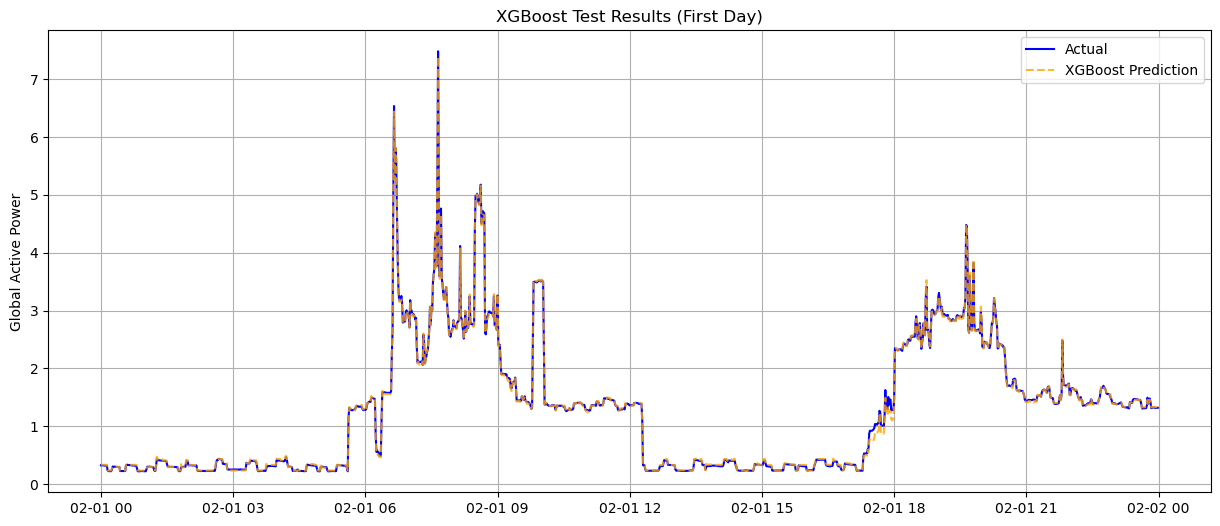

In [295]:
plt.figure(figsize=(15, 6))
subset = 1440 

plt.plot(y_test.index[:subset], y_test.iloc[:subset], label='Actual', color='blue', linewidth=1.5)
plt.plot(y_test.index[:subset], xg_pred[:subset], label='XGBoost Prediction', color='orange', linestyle='--', alpha=0.8)

plt.title('XGBoost Test Results (First Day)')
plt.ylabel('Global Active Power')
plt.legend()
plt.grid(True)

### Сравнение метрик моделей (Train/Val vs Test)

| Модель | Train MAE | Train RMSE | Test MAE | Test RMSE |
| :--- | :--- | :--- | :--- | :--- |
| **Linear Regression** | 0.02961 | 0.05189 | 0.03026 | 0.04985 |
| **Gradient Boosting** | 0.02330 | 0.04075 | 0.02419 | 0.04196 |
| **Random Forest** | 0.02640 | 0.04757 | 0.02734 | 0.04745 |
| **XGBoost** | **0.02326** | **0.04085** | **0.02411** | **0.04159** |


